**Author:** Christopher Millward<br>
**Date:** June 29, 2026

This is a continuation of the `03-cm-pilot-check-for-normalized-matrices.ipynb` notebook. It turns out the quaternions were not normalized before convering to R matrices, which caused all the previous issues. The pilot looked good, so I'm going to just run the same audit as in `01-cm-data-orthonormality-audit.ipynb` on the new data.

---

I'm going to perform the following audits:
1. Calculate how far away from orthonormality each R matrix is in each data file. 
2. Visualize the distributions of these variances
3. Plot the variances on a time series to assess stability / drift.

In [10]:
# set root folder to project root
import os 
import sys

root_path = os.path.abspath(os.path.join(".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

# auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# Import the data
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from utils.data_loading import load_participant_details
from utils.kinematics.general_helpers import create_rotation_matrices

participant_details = load_participant_details('../data/raw_normalized_data/participant_details.xlsx')

In [14]:
# Helper functions
def calculate_and_save_variances(data, rtsa_side, fpath):
    """Helper function to calculate and save variances for a single arm"""

    # build matrices
    matrices = create_rotation_matrices(data, rtsa_side)

    # calculate variance from orthonormality
    I = np.eye(3)
    ortho_variance_arrays = (np.transpose(matrices, axes=(0, 2, 1)) @ matrices - I)
    variances = np.linalg.norm(ortho_variance_arrays, axis=(1, 2))

    # save variances
    variance_data.extend(
        {
            "participant": fpath,
            "variance": v,
        }
        for v in variances
    )

# Analysis
variance_data = []
for participant in participant_details:
    # get data
    fpath = participant['filename']
    side = participant['rtsa_side']
    
    if side is None:
        continue  # Skip participants with no RTSA side information

    data = np.loadtxt(
        f'../data/raw_normalized_data/{fpath}', delimiter='\t', skiprows=1, usecols=range(1, 19))

    # Run analysis
    calculate_and_save_variances(data, side, fpath)

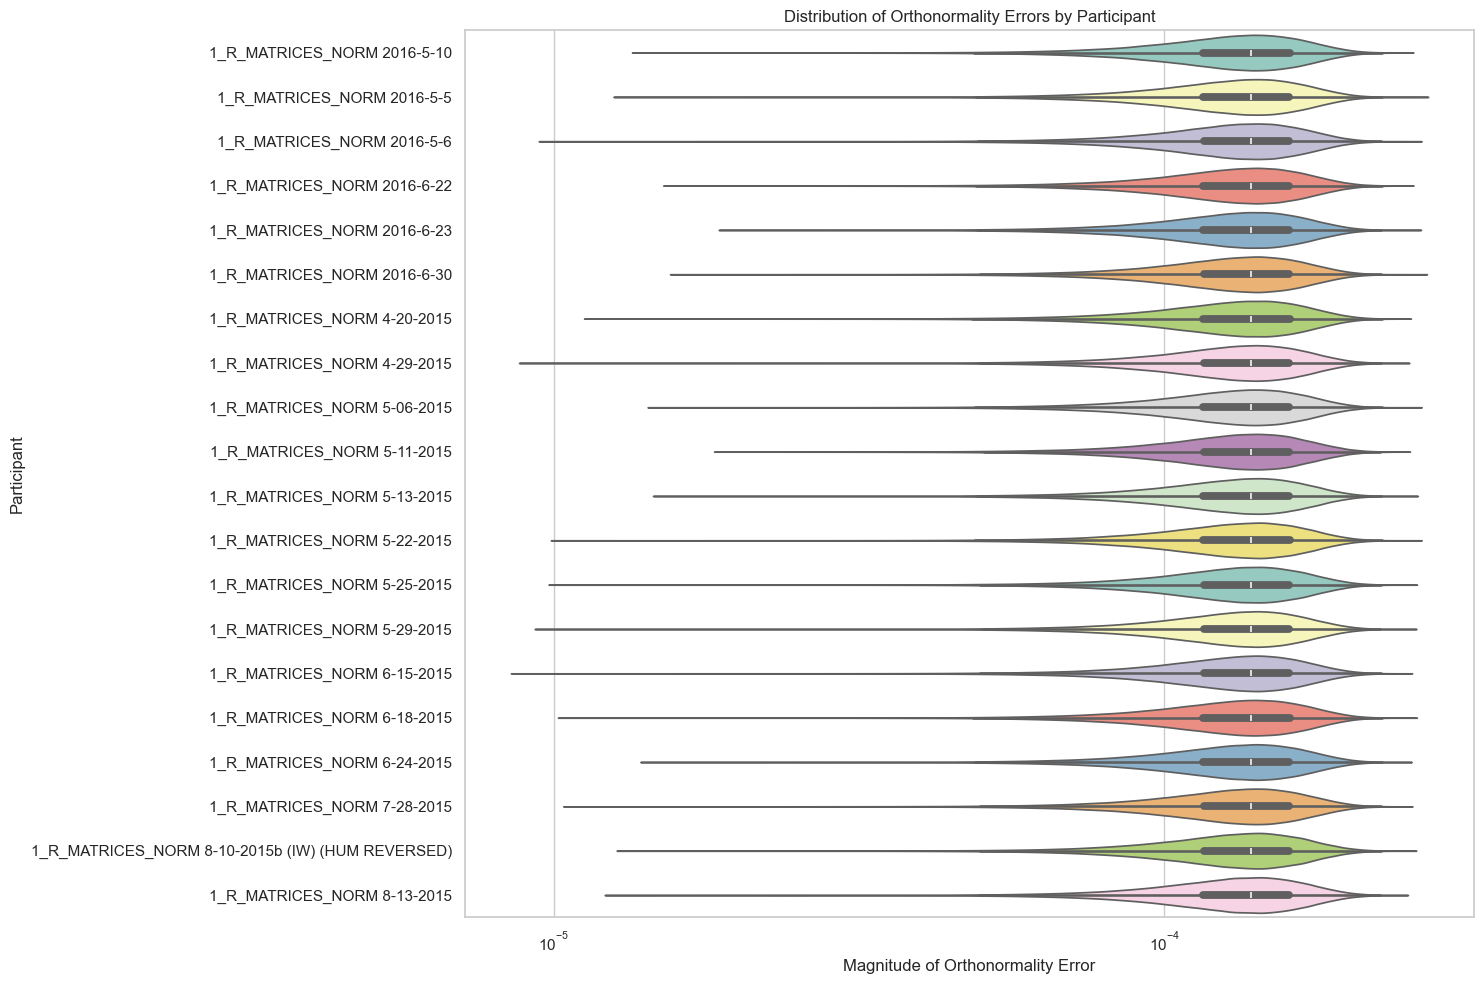

In [15]:
# Plot distributions
sns.set_theme(style="whitegrid", context="notebook")
plot_data = pd.DataFrame(variance_data)

plt.figure(figsize=(15, 10))

sns.violinplot(
    data=plot_data,
    y="participant",
    x="variance",
    cut=0,
    palette="Set3",
    hue="participant",
    legend=False,
)

plt.xscale("log")
plt.title("Distribution of Orthonormality Errors by Participant")
plt.xlabel("Magnitude of Orthonormality Error")
plt.ylabel("Participant")
plt.tight_layout()
plt.show()

In [16]:
print("=== Participant-Level Variance Descriptions ===")
print(plot_data.groupby("participant")["variance"].describe().to_markdown())

print("\n\n=== Overall Variance Description ===")
all_descr = plot_data.groupby("participant")["variance"].describe()['mean'].describe()
print(all_descr.to_markdown())

=== Participant-Level Variance Descriptions ===
| participant                                      |   count |        mean |         std |         min |         25% |         50% |         75% |         max |
|:-------------------------------------------------|--------:|------------:|------------:|------------:|------------:|------------:|------------:|------------:|
| 1_R_MATRICES_NORM 2016-5-10                      |  405461 | 0.000137714 | 3.2282e-05  | 1.34299e-05 | 0.000115882 | 0.000138743 | 0.000160552 | 0.000256048 |
| 1_R_MATRICES_NORM 2016-5-5                       |  404913 | 0.000137767 | 3.22238e-05 | 1.25241e-05 | 0.000115979 | 0.00013883  | 0.000160479 | 0.000270826 |
| 1_R_MATRICES_NORM 2016-5-6                       |  458935 | 0.00013771  | 3.21241e-05 | 9.44695e-06 | 0.000116041 | 0.000138686 | 0.000160329 | 0.000264181 |
| 1_R_MATRICES_NORM 2016-6-22                      |  233732 | 0.000137657 | 3.22351e-05 | 1.51093e-05 | 0.000115904 | 0.000138712 | 0.000160403 | 

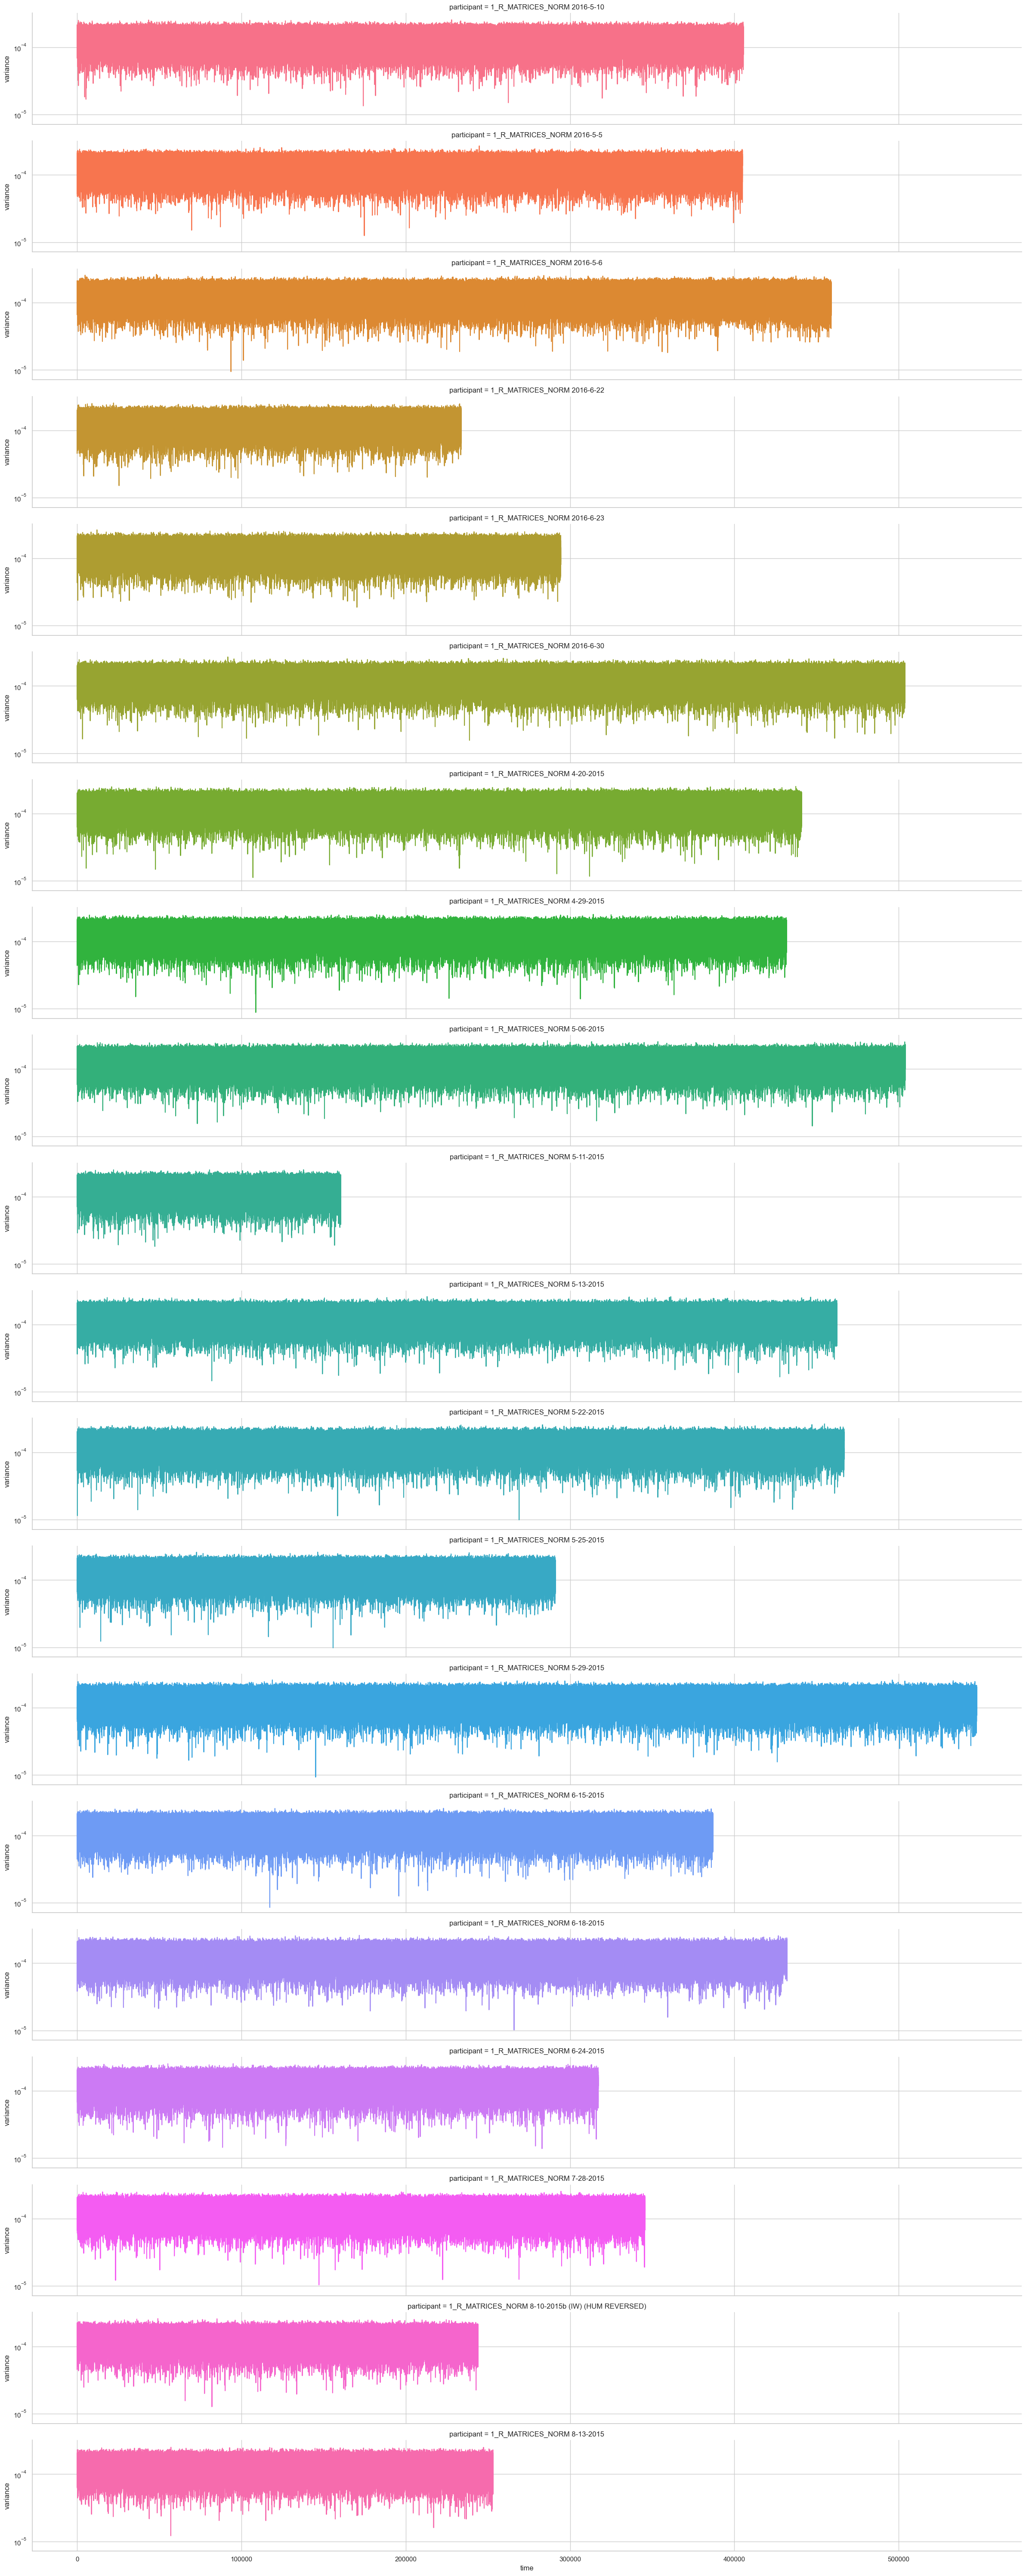

In [17]:
# Create a common x-axis for all participants
plot_data["time"] = plot_data.groupby("participant").cumcount()

# Plot the orthonormality errors on a time-series
sns.set_theme(style="whitegrid", context="notebook")

sns.relplot(
    data=plot_data,
    x="time",
    y="variance",
    col="participant",  # creates a new subplot column for each participant
    col_wrap=1,  # adjusts how many subplots appear per row
    kind="line",
    facet_kws=dict(
        sharey=True, 
        sharex=True
    ),
    height=3,  # height of each individual subplot
    aspect=8,  # width-to-height ratio of each subplot
    hue="participant",
    legend = False
)

plt.yscale("log")
plt.tight_layout()
plt.show()

This dataset looks much better. The orthonormality variances are all less than 1e-4 and are quite stable. I am confident moving forward with this dataset.